#Step 1 - Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/final_uci_drug_review_ADE_sentiment.csv")

print(df.shape)
df.head()

(161297, 15)


,uniqueID,drugName,condition,review,rating,date,usefulCount,ade_entities,ade_count,silver_label,max_confidence,max_severity,max_frequency,sentiment,sentiment_score
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,[],0,0,0.000,0,0,Neutral,0.646
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,['cranky'],1,1,0.806,0,0,Neutral,0.435
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,['brown discharge'],1,1,0.920,0,5,Neutral,0.502
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,[],0,0,0.000,0,0,Positive,0.847
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,['constipation'],1,1,0.950,1,0,Positive,0.899


In [ ]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    "Missing",
    ascending=False
)

,Missing,Percentage
condition,2058,1.28
uniqueID,0,0.00
drugName,0,0.00
review,0,0.00
rating,0,0.00
date,0,0.00
usefulCount,0,0.00
ade_entities,0,0.00
ade_count,0,0.00
silver_label,0,0.00


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.shape)
print(df.isnull().sum())

(159239, 15)
uniqueID           0
drugName           0
condition          0
review             0
rating             0
date               0
usefulCount        0
ade_entities       0
ade_count          0
silver_label       0
max_confidence     0
max_severity       0
max_frequency      0
sentiment          0
sentiment_score    0
dtype: int64


In [ ]:
print(df.columns.tolist())

['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'ade_entities', 'ade_count', 'silver_label', 'max_confidence', 'max_severity', 'max_frequency', 'sentiment', 'sentiment_score']


#STEP 2 —   Select Required Columns

Association Rule Mining only needs the structured information that represents meaningful events.

We'll keep:
1. Drug
2. ADE(s)
3. Sentiment
4. Severity
5. Frequency

In [ ]:
arm_df = df[
    [
        "drugName",
        "ade_entities",
        "sentiment",
        "max_severity",
        "max_frequency"
    ]
].copy()

arm_df.head()

,drugName,ade_entities,sentiment,max_severity,max_frequency
0,Valsartan,[],Neutral,0,0
1,Guanfacine,['cranky'],Neutral,0,0
2,Lybrel,['brown discharge'],Neutral,0,5
3,Ortho Evra,[],Positive,0,0
4,Buprenorphine / naloxone,['constipation'],Positive,1,0


#STEP 3 — Convert ADE Strings Back into Lists

In [ ]:
import ast

arm_df["ade_entities"] = arm_df["ade_entities"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

In [ ]:
print(type(arm_df["ade_entities"].iloc[1]))
print(arm_df["ade_entities"].iloc[1])

<class 'list'>
['cranky']


#Step 4 – Keep Reviews Containing ADEs
Association Rule Mining aims to discover relationships between drugs and adverse drug events. Reviews without any detected ADEs cannot contribute to these associations and are therefore removed.

In [ ]:
# ==========================================================
# Step 4: Keep Reviews with Extracted ADEs
# ==========================================================

arm_df = arm_df[
    arm_df["ade_entities"].apply(len) > 0
].copy()

print("After removing reviews without ADEs:")
print(arm_df.shape)

After removing reviews without ADEs:
(110282, 5)


#Step 5 – Keep Frequently Occurring Drugs
Rare drugs often produce statistically weak association rules while substantially increasing computational complexity. Therefore, only drugs appearing at least a specified number of times are retained.

In [ ]:
# ==========================================================
# Step 5: Keep Frequently Occurring Drugs
# ==========================================================

MIN_DRUG_COUNT = 200

drug_counts = arm_df["drugName"].value_counts()

frequent_drugs = drug_counts[
    drug_counts >= MIN_DRUG_COUNT
].index

arm_df = arm_df[
    arm_df["drugName"].isin(frequent_drugs)
].copy()

print("After filtering frequent drugs:")
print(arm_df.shape)

print("Number of drugs retained:", len(frequent_drugs))

After filtering frequent drugs:
(59492, 5)
Number of drugs retained: 122


#Step 6 – Keep Frequently Occurring ADEs
Similarly, rare ADEs are removed because they generate sparse and statistically unreliable association rules.

In [ ]:
# ==========================================================
# Step 6: Keep Frequently Occurring ADEs
# ==========================================================

from collections import Counter

MIN_ADE_COUNT = 100

ade_counter = Counter()

for ade_list in arm_df["ade_entities"]:
    ade_counter.update(ade_list)

frequent_ades = {
    ade
    for ade, count in ade_counter.items()
    if count >= MIN_ADE_COUNT
}

print("Number of frequent ADEs:", len(frequent_ades))

Number of frequent ADEs: 171


In [ ]:
# Keep only frequent ADEs

arm_df["ade_entities"] = arm_df["ade_entities"].apply(
    lambda ade_list: [
        ade
        for ade in ade_list
        if ade in frequent_ades
    ]
)

#Step 7 – Remove Empty Transactions After Filtering
Some reviews may contain only rare ADEs. After filtering, these reviews no longer contain any ADEs and therefore cannot contribute to association rule mining.

In [ ]:
# ==========================================================
# Step 7: Remove Empty Transactions
# ==========================================================

arm_df = arm_df[
    arm_df["ade_entities"].apply(len) > 0
].copy()

print("Final dataset for Association Rule Mining:")
print(arm_df.shape)

Final dataset for Association Rule Mining:
(50182, 5)


In [ ]:
print("Number of remaining drugs:",
      arm_df["drugName"].nunique())

all_ades = set()

for ade_list in arm_df["ade_entities"]:
    all_ades.update(ade_list)

print("Number of remaining ADEs:",
      len(all_ades))

Number of remaining drugs: 122
Number of remaining ADEs: 171


#STEP 8 — Convert Severity Scores to Categories

In [ ]:
severity_map = {
    0: "None",
    1: "Mild",
    2: "Moderate",
    3: "Bad",
    4: "Severe",
    5: "Extreme"
}

arm_df["severity"] = arm_df["max_severity"].map(severity_map)

In [ ]:
arm_df[["max_severity", "severity"]].head()

,max_severity,severity
7,0,None
9,0,None
10,5,Extreme
15,4,Severe
18,0,None


#Step 9 — Convert Frequency Scores to Categories

In [ ]:
frequency_map = {
    0: "None",
    1: "Once",
    2: "Occasional",
    3: "Often",
    4: "Frequent",
    5: "Daily_or_Always"
}

arm_df["frequency"] = arm_df["max_frequency"].map(frequency_map)

In [ ]:
arm_df[["max_frequency", "frequency"]].head()

,max_frequency,frequency
7,0,None
9,0,None
10,0,None
15,1,Once
18,0,None


#Step 10 – Construct Transactions
Association Rule Mining algorithms such as Apriori and FP-Growth do not work directly with tables. Instead, they require each record (review) to be represented as a transaction, where every attribute is treated as an item.

In this study, each patient review is converted into a transaction containing:

1. Drug name
2. Extracted ADE(s)
3. Sentiment
4. Severity
5. Frequency

In [ ]:
# ==========================================================
# Step 10: Construct Transactions
# ==========================================================

transactions = []

for _, row in arm_df.iterrows():

    transaction = []

    # --------------------------------------------------
    # Drug
    # --------------------------------------------------
    transaction.append(
        "Drug_" + str(row["drugName"])
    )

    # --------------------------------------------------
    # ADEs
    # --------------------------------------------------
    for ade in row["ade_entities"]:
        transaction.append(
            "ADE_" + str(ade)
        )

    # --------------------------------------------------
    # Sentiment
    # --------------------------------------------------
    transaction.append(
        "Sentiment_" + str(row["sentiment"])
    )

    # --------------------------------------------------
    # Severity
    # (Skip None)
    # --------------------------------------------------
    if row["severity"] != "None":
        transaction.append(
            "Severity_" + str(row["severity"])
        )

    # --------------------------------------------------
    # Frequency
    # (Skip None)
    # --------------------------------------------------
    if row["frequency"] != "None":
        transaction.append(
            "Frequency_" + str(row["frequency"])
        )

    transactions.append(transaction)

In [ ]:
print("Total Transactions:", len(transactions))

transactions[:5]

Total Transactions: 50182


[['Drug_Aripiprazole', 'ADE_depression', 'Sentiment_Positive'],
 ['Drug_Ethinyl estradiol / levonorgestrel',
  'ADE_acne',
  'ADE_depression',
  'ADE_weight gain',
  'Sentiment_Positive'],
 ['Drug_Topiramate',
  'ADE_weight loss',
  'Sentiment_Positive',
  'Severity_Extreme'],
 ['Drug_Liraglutide',
  'ADE_constipation',
  'ADE_nausea',
  'ADE_weight loss',
  'Sentiment_Neutral',
  'Severity_Severe',
  'Frequency_Once'],
 ['Drug_Lamotrigine', 'ADE_anxiety', 'ADE_mania', 'Sentiment_Neutral']]

In [ ]:
transaction_lengths = [len(t) for t in transactions]

print("Minimum items:", min(transaction_lengths))
print("Maximum items:", max(transaction_lengths))
print("Average items per transaction:",
      sum(transaction_lengths) / len(transaction_lengths))

Minimum items: 3
Maximum items: 18
Average items per transaction: 4.30469092503288


#Step 11 – One-Hot Encode the Transactions
The transactions created in the previous step are stored as lists of items. However, Apriori and FP-Growth require the data to be represented as a binary (one-hot encoded) matrix, where:

1. Each row represents one patient review (transaction).
Each column represents one unique item (e.g., Drug, ADE, Sentiment, Severity, Frequency).
2. A value of True (1) indicates that the item is present in the transaction, while False (0) indicates its absence.

In [ ]:
!pip install mlxtend

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

In [ ]:
# Initialize encoder
te = TransactionEncoder()

# Transform transactions into binary format
te_array = te.fit(transactions).transform(transactions)

# Create one-hot encoded DataFrame
basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

In [ ]:
print("Basket Shape:", basket.shape)

basket.head()

Basket Shape: (50182, 306)


,ADE_abdominal pain,ADE_acne,ADE_agitation,ADE_allergic reaction,ADE_anemia,ADE_anxiety,ADE_anxiety attacks,ADE_back pain,ADE_bad cramps,ADE_bad headaches,...,Frequency_Often,Frequency_Once,Sentiment_Negative,Sentiment_Neutral,Sentiment_Positive,Severity_Bad,Severity_Extreme,Severity_Mild,Severity_Moderate,Severity_Severe
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
print("Number of unique items:", len(basket.columns))

Number of unique items: 306


#APRIORI ALGORITHM

The Apriori algorithm is applied to discover frequent itemsets from the transaction database using a minimum support threshold of 0.006.

#Step 12 – Mine Frequent Itemsets using Apriori
The Apriori algorithm identifies groups of items that frequently occur together across all patient reviews. Instead of generating rules immediately, Apriori first discovers frequent itemsets, which are combinations of items that satisfy a minimum support threshold.

In [ ]:
from mlxtend.frequent_patterns import apriori

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.006,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("Number of Frequent Itemsets:", len(frequent_itemsets))

frequent_itemsets.head(20)

Number of Frequent Itemsets: 342


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.498226,(Sentiment_Negative)
1,0.306405,(Sentiment_Positive)
2,0.195369,(Sentiment_Neutral)
3,0.162648,(ADE_anxiety)
4,0.116775,(ADE_nausea)
5,0.112929,(ADE_depression)
6,0.088179,(Severity_Extreme)
7,0.087282,(Severity_Severe)
8,0.084971,(ADE_mood swings)
9,0.080288,"(Sentiment_Negative, ADE_anxiety)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Step 13 – Generate Association Rules
After identifying frequent itemsets using the Apriori algorithm, the next step is to generate association rules. These rules describe relationships between items in the dataset in the form:

**Antecedent  →  Consequent**

For example:
**Drug_Metformin → ADE_Diarrhea**

means that reviews mentioning Metformin are frequently associated with Diarrhea.

Each rule is evaluated using three important metrics:
1. Support – How frequently the rule appears in the dataset.
2. Confidence – How often the consequent occurs when the antecedent is present.
3. Lift – Measures the strength of the association beyond random chance.

Import rules

In [ ]:
from mlxtend.frequent_patterns import association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Generate Rules

In [ ]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules = rules.sort_values(
    by="lift",
    ascending=False
).reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules["antecedents"] = rules["antecedents"].apply(
    lambda x: ", ".join(list(x))
)

rules["consequents"] = rules["consequents"].apply(
    lambda x: ", ".join(list(x))
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,Drug_Miconazole,"Sentiment_Negative, ADE_itching",0.006795,0.601411,40.293730
1,Drug_Miconazole,ADE_itching,0.007951,0.703704,35.242774
2,"Sentiment_Negative, Drug_Miconazole",ADE_itching,0.006795,0.703093,35.212178
3,Drug_Phentermine,ADE_dry mouth,0.007632,0.583841,17.224181
4,Drug_Citalopram,ADE_anxiety,0.008489,0.611191,3.757753
5,Drug_Zoloft,ADE_anxiety,0.006835,0.596522,3.667564
6,Drug_Sertraline,ADE_anxiety,0.011618,0.594898,3.657580
7,Drug_Miconazole,Sentiment_Negative,0.009665,0.855379,1.716848
8,"Drug_Miconazole, ADE_itching",Sentiment_Negative,0.006795,0.854637,1.715358
9,"Severity_Extreme, ADE_nausea",Sentiment_Negative,0.012455,0.787154,1.579911


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Step 14 - Drug → ADE

In [ ]:
drug_ade = rules[
    rules["antecedents"].str.contains("Drug_", na=False) &
    rules["consequents"].str.contains("ADE_", na=False)
]

print("Drug → ADE Rules:", len(drug_ade))

drug_ade.sort_values(by="lift", ascending=False).head(20)

Drug → ADE Rules: 7


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,Drug_Miconazole,"Sentiment_Negative, ADE_itching",0.011299,0.014926,0.006795,0.601411,40.293730,1.0,0.006627,2.471403,0.986327,0.349744,0.595372,0.528342
1,Drug_Miconazole,ADE_itching,0.011299,0.019967,0.007951,0.703704,35.242774,1.0,0.007725,3.307610,0.982729,0.341026,0.697667,0.550954
2,"Sentiment_Negative, Drug_Miconazole",ADE_itching,0.009665,0.019967,0.006795,0.703093,35.212178,1.0,0.006602,3.300805,0.981083,0.297557,0.697044,0.521706
3,Drug_Phentermine,ADE_dry mouth,0.013072,0.033897,0.007632,0.583841,17.224181,1.0,0.007189,2.321479,0.954419,0.194022,0.569240,0.404502
4,Drug_Citalopram,ADE_anxiety,0.013889,0.162648,0.008489,0.611191,3.757753,1.0,0.006230,2.153632,0.744220,0.050516,0.535668,0.331692
5,Drug_Zoloft,ADE_anxiety,0.011458,0.162648,0.006835,0.596522,3.667564,1.0,0.004971,2.075334,0.735770,0.040863,0.518150,0.319273
6,Drug_Sertraline,ADE_anxiety,0.019529,0.162648,0.011618,0.594898,3.657580,1.0,0.008441,2.067015,0.741067,0.068115,0.516211,0.333163


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##SAVE CSV

In [ ]:
drug_ade.to_csv(
    "/content/drive/MyDrive/drug_ade_rules.csv",
    index=False
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from google.colab import files

files.download("association_rules_final.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/drug_ade_rules.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#FP-GROWTH ALGORITHM

In [ ]:
import time
from mlxtend.frequent_patterns import fpgrowth

start = time.time()

fp_itemsets = fpgrowth(
    basket,
    min_support=0.006,
    use_colnames=True
)

end = time.time()

fp_time = end - start

print("FP-Growth Runtime:", fp_time, "seconds")
print("Frequent Itemsets:", len(fp_itemsets))

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

##Step 15 - Generate Rules

In [ ]:
from mlxtend.frequent_patterns import association_rules

fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.5
)

print("Total Rules:", len(fp_rules))

##Step 16 — Convert frozensets to strings

In [ ]:
fp_rules["antecedents"] = fp_rules["antecedents"].apply(
    lambda x: ", ".join(list(x))
)

fp_rules["consequents"] = fp_rules["consequents"].apply(
    lambda x: ", ".join(list(x))
)

##Step 17 — Drug→ADE rules

In [ ]:
fp_drug_ade = fp_rules[
    fp_rules["antecedents"].str.contains("Drug_", na=False) &
    fp_rules["consequents"].str.contains("ADE_", na=False)
]

print("Drug→ADE Rules:", len(fp_drug_ade))

fp_drug_ade.sort_values(
    by="lift",
    ascending=False
).head(20)

##SAVE CSV

In [ ]:
fp_rules.to_csv(
    "/content/drive/MyDrive/fpgrowth_rules.csv",
    index=False
)

fp_drug_ade.to_csv(
    "/content/drive/MyDrive/fpgrowth_drug_ade_rules.csv",
    index=False
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#Compare Apriori vs FP-Growth

In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "Frequent Itemsets",
        "Total Rules",
        "Drug→ADE Rules"
    ],
    "Apriori": [
        len(frequent_itemsets),
        len(rules),
        len(drug_ade)
    ],
    "FP-Growth": [
        len(fp_itemsets),
        len(fp_rules),
        len(fp_drug_ade)
    ]
})

comparison

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Metric,Apriori,FP-Growth
0,Frequent Itemsets,342,342
1,Total Rules,75,75
2,Drug→ADE Rules,7,7


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Interpretation
- Apriori discovered 342 frequent itemsets and 75 association rules.
- FP-Growth produced identical frequent itemsets and association rules.
- Both algorithms identified seven clinically meaningful Drug→ADE associations.
- FP-Growth offers a computational advantage for larger datasets because it avoids candidate generation.

#Visualizations

##Top Drug→ADE Rules by Lift

Purpose: Shows the strongest discovered associations.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

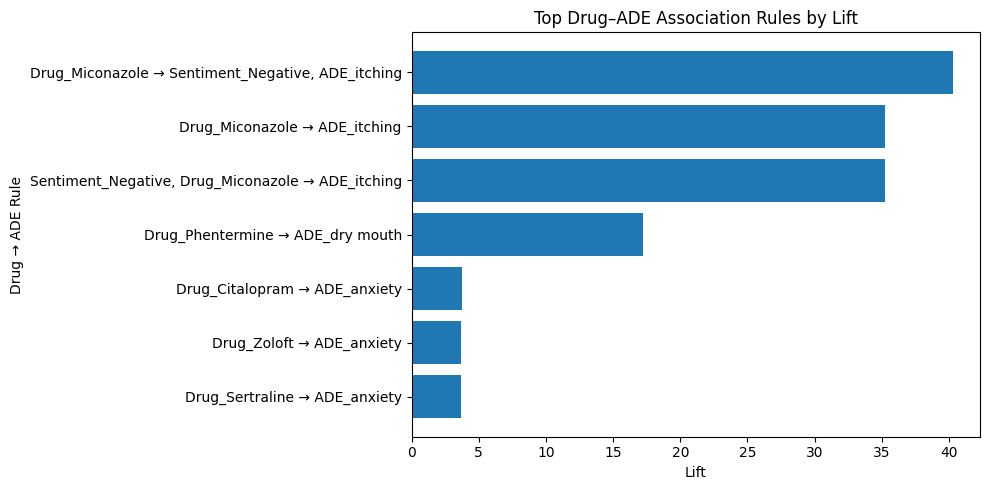

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

# Copy and sort
plot_df = fp_drug_ade.copy()

plot_df = plot_df.sort_values(
    by="lift",
    ascending=True
)

plt.figure(figsize=(10,5))

plt.barh(
    plot_df["antecedents"] + " → " + plot_df["consequents"],
    plot_df["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Drug → ADE Rule")
plt.title("Top Drug–ADE Association Rules by Lift")

plt.tight_layout()
plt.show()

##Top Drug→ADE Rules by Confidence

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

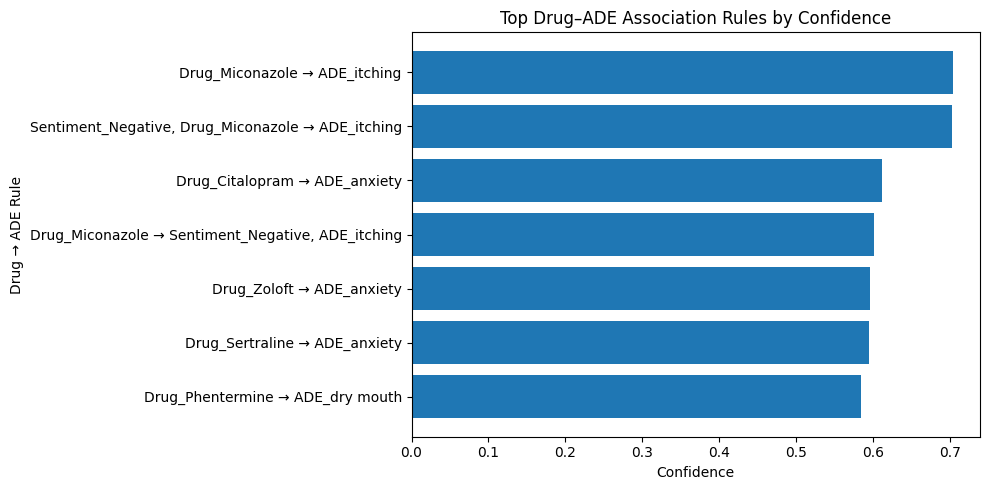

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

plot_df = fp_drug_ade.copy()

plot_df = plot_df.sort_values(
    by="confidence",
    ascending=True
)

plt.figure(figsize=(10,5))

plt.barh(
    plot_df["antecedents"] + " → " + plot_df["consequents"],
    plot_df["confidence"]
)

plt.xlabel("Confidence")
plt.ylabel("Drug → ADE Rule")
plt.title("Top Drug–ADE Association Rules by Confidence")

plt.tight_layout()
plt.show()